# Estimación de Edad a partir de Imágenes Faciales

## Librerías

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Manipulación de datos
import pandas as pd

# Procesamiento de imágenes
import cv2

# División de datos y métricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 1. Análisis Preliminar del Problema

**a. ¿Por qué es un problema de regresión?**

Queremos predecir la edad exacta de una persona a partir de su foto. La edad es un valor numérico continuo, así que el modelo tiene que dar una respuesta concreta como "34 años" o "67 años", no una categoría como "joven" o "adulto". Eso es lo que hace la regresión: estimar un valor. Si lo tratáramos como clasificación perderíamos toda la precisión del número. La variable objetivo es la edad, que se extrae directamente del nombre de cada imagen.

**b. Características de entrada**

Son imágenes de caras en color (espacio RGB, 3 canales). El dataset tiene 3250 imágenes del conjunto UTKFace con edades entre 1 y 116 años. El nombre de cada archivo incluye la edad en el formato `edad_genero_raza_timestamp.jpg`, por ejemplo `27_0_1_20170120133818199.jpg` es una persona de 27 años, así que no se necesita un archivo de etiquetas separado. Los tamaños de las imágenes no son uniformes, lo que significa que hay que redimensionarlas antes de entrenar el modelo.

**c. Protocolo de adquisición de datos**

Las imágenes vienen del conjunto UTKFace, un dataset académico que recolecta fotos de personas con diferentes edades, géneros y etnias capturadas en condiciones variadas: distintos fondos, iluminaciones y ángulos. Las edades fueron asignadas manualmente a cada imagen. Esta diversidad hace que el modelo tenga que aprender características reales del envejecimiento facial y no simplemente depender de condiciones controladas de la foto.

## 2. Análisis Exploratorio de Datos (EDA)

### Carga del dataset

In [2]:
RUTA_IMAGENES = '../data/faces/archive/faces_02/part3'

# Cada imagen tiene el formato: edad_genero_raza_timestamp.jpg
# Se extrae la edad del primer número en el nombre
archivos = []
edades = []

for nombre in os.listdir(RUTA_IMAGENES):
    if not nombre.endswith('.jpg'):
        continue
    try:
        edad = int(nombre.split('_')[0])
        archivos.append(nombre)
        edades.append(edad)
    except ValueError:
        continue

df = pd.DataFrame({'image_name': archivos, 'age': edades})
df['age'] = df['age'].astype(int)

print("Muestras:", len(df))
print("Rango de edad:", df['age'].min(), "–", df['age'].max())
df.head()

Muestras: 3250
Rango de edad: 1 – 116


,image_name,age
0,27_0_1_20170120133818199.jpg,27
1,24_0_3_20170119165522935.jpg,24
2,8_1_0_20170117154607954.jpg,8
3,85_1_0_20170120222635457.jpg,85
4,26_1_0_20170119192908266.jpg,26


### Estadísticos de edad

In [3]:
print(df['age'].describe().to_string())
print("\nMediana:", int(df['age'].median()))

count    3250.000000
mean       40.550769
std        17.309044
min         1.000000
25%        26.000000
50%        35.000000
75%        53.000000
max       116.000000

Mediana: 35


El dataset tiene 3250 imágenes. La edad promedio es 40.5 años pero la mediana es 35, lo que indica que la distribución no es simétrica: hay personas de edad muy avanzada que jalan el promedio hacia arriba. El 50% de las fotos corresponde a personas entre 26 y 53 años, y el rango completo va de 1 a 116 años. Aunque hay bastante variedad de edades, el dataset está claramente concentrado en adultos.

### Distribución de edades

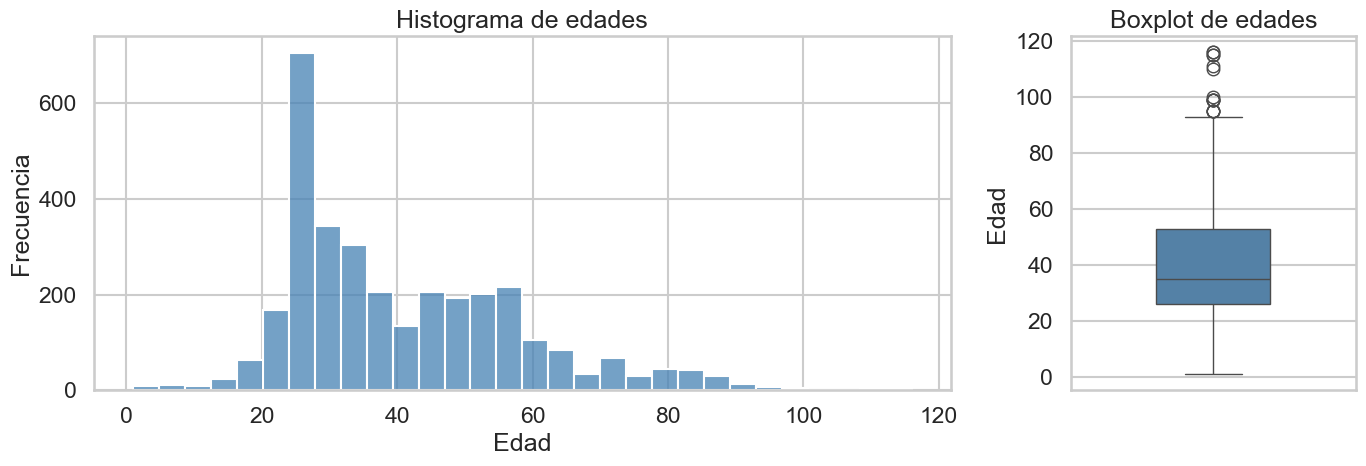

In [4]:
sns.set_style("whitegrid")
sns.set_context("talk")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})

sns.histplot(df['age'], bins=30, ax=axes[0], color='steelblue')
axes[0].set_title('Histograma de edades')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

sns.boxplot(y=df['age'], ax=axes[1], color='steelblue', width=0.4)
axes[1].set_title('Boxplot de edades')
axes[1].set_ylabel('Edad')

plt.tight_layout()
plt.show()

La mayor concentración de imágenes está entre los 20 y los 40 años, con una caída progresiva hacia edades más altas. La distribución está sesgada hacia la derecha, lo que se confirma porque la media (40.5) es mayor que la mediana (35): hay personas de edad avanzada que estiran la cola superior pero son pocos casos. Esto implica que el modelo va a predecir mejor en el rango central donde hay más datos, y probablemente va a tener mayor error en edades extremas como bebés o personas de más de 80 años.

### Análisis de balance y sesgos

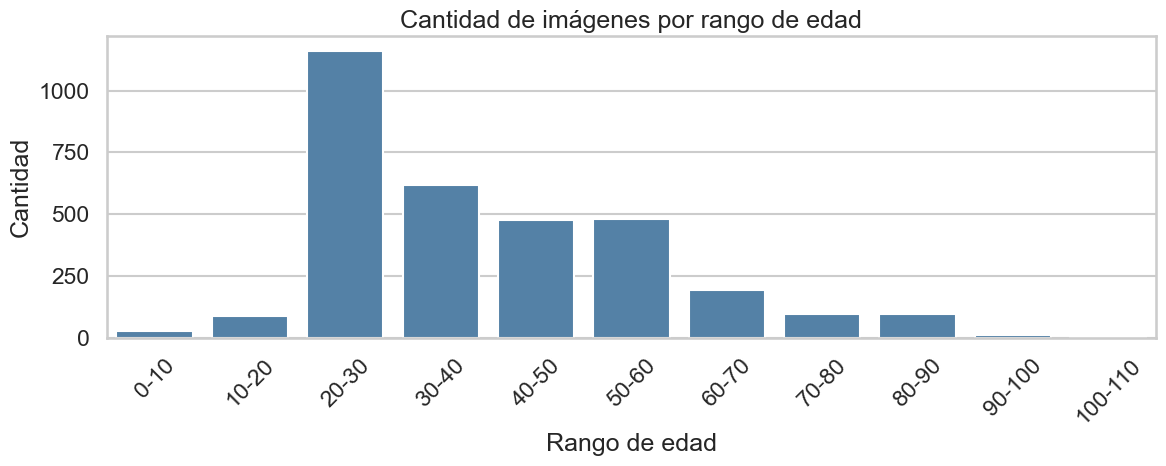

Rango más frecuente: (20, 30]
Rango menos frecuente: (100, 110]


In [5]:
df['rango_edad'] = pd.cut(df['age'], bins=range(0, 120, 10))
conteo = df['rango_edad'].value_counts().sort_index()
etiquetas = [f'{i}-{i+10}' for i in range(0, 110, 10)]

plt.figure(figsize=(12, 5))
sns.barplot(x=etiquetas[:len(conteo)], y=conteo.values, color='steelblue', errorbar=None)
plt.title('Cantidad de imágenes por rango de edad')
plt.xlabel('Rango de edad')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Rango más frecuente:", conteo.idxmax())
print("Rango menos frecuente:", conteo.idxmin())

El rango 20–30 tiene la mayor cantidad de fotos, con bastante diferencia sobre los demás. A partir de los 50 años la cantidad de imágenes cae progresivamente, y los rangos de más de 70 son los menos representados. Este desbalance va a afectar el entrenamiento: el modelo va a ver muchos más ejemplos de adultos jóvenes que de personas mayores, así que es esperable que cometa errores más grandes en edades extremas. Es importante tenerlo en cuenta al momento de evaluar las métricas.

### Visualización de muestras

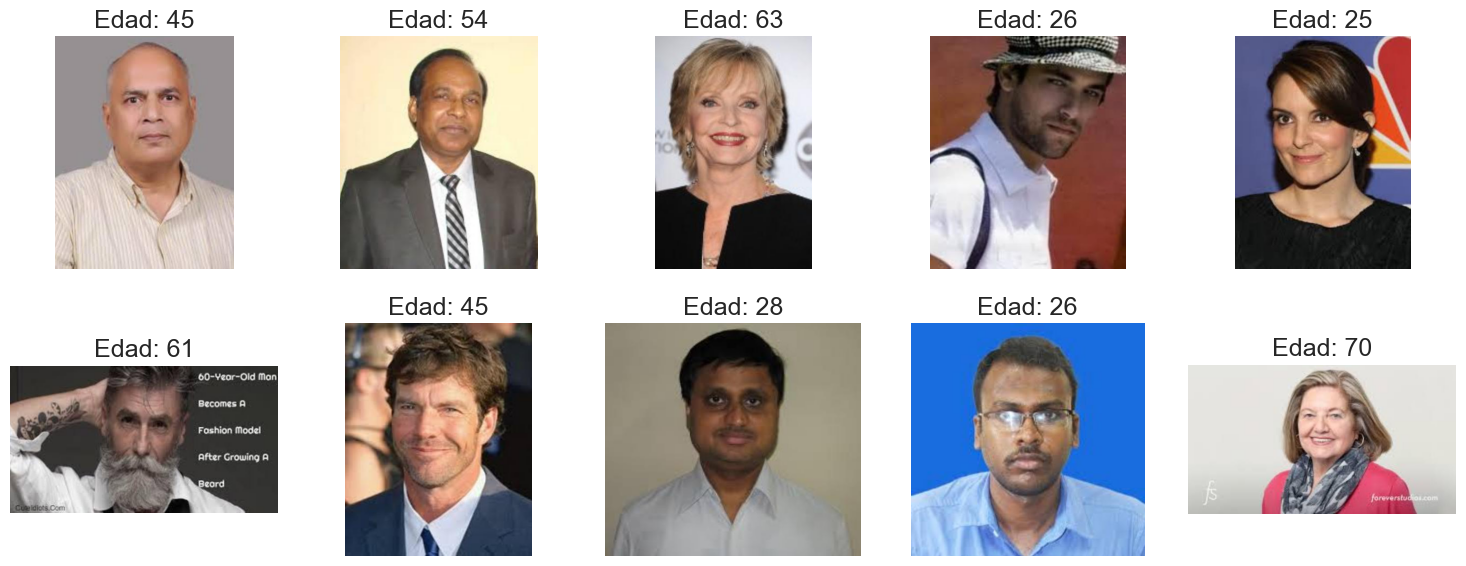

In [6]:
indices = np.random.choice(len(df), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for i in range(10):
    indice = indices[i]
    nombre = df['image_name'].iloc[indice]
    edad = df['age'].iloc[indice]
    ruta = os.path.join(RUTA_IMAGENES, nombre)
    img = plt.imread(ruta)
    axes[i].imshow(img)
    axes[i].set_title('Edad: ' + str(edad))
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Las imágenes muestran diversidad en personas, fondos e iluminación, lo que hace que el dataset sea representativo de condiciones reales. En general las etiquetas se ven correctas: las personas con edades altas tienen rasgos visiblemente distintos a los de personas jóvenes. También se nota variación en calidad fotográfica, con algunas fotos más borrosas o con menos luz. Eso implica que el modelo no puede depender de condiciones ideales y tiene que aprender características propias de la edad como textura de piel o rasgos faciales.

### Calidad y variabilidad de las imágenes

In [7]:
alturas = []
anchos = []
faltantes = 0

for nombre in df['image_name'].iloc[:100]:
    ruta = os.path.join(RUTA_IMAGENES, nombre)
    img = cv2.imread(ruta)
    if img is None:
        faltantes += 1
        continue
    alto, ancho, canales = img.shape
    alturas.append(alto)
    anchos.append(ancho)

print("Imágenes revisadas:", len(alturas))
print("Imágenes faltantes:", faltantes)
print("Alto  — min:", min(alturas), " max:", max(alturas))
print("Ancho — min:", min(anchos), " max:", max(anchos))

Imágenes revisadas: 100
Imágenes faltantes: 0
Alto  — min: 201  max: 1189
Ancho — min: 140  max: 794


Los tamaños de las imágenes son muy variados: el alto va de 201 a 1189 píxeles y el ancho de 140 a 794. Esta variabilidad confirma que hay que redimensionarlas todas a un tamaño fijo antes de pasarlas a la red, ya que una CNN necesita que todas las entradas tengan la misma dimensión. Lo bueno es que no hay imágenes faltantes, así que el dataset está completo.